# TellCo Telecom User Analytics — Growth & Acquisition Analysis

**Prepared for:** Investor Due Diligence Team
**Prepared by:** Ashish Kumar, Nexthikes IT Solutions
**Objective:** Analyze one month of xDR (data session) records from TellCo, a mobile service provider in the Republic of Pefkakia, to assess growth opportunities and provide a buy/sell recommendation.

This notebook covers all four analytical objectives:
1. **User Overview Analysis** — device landscape & session-level EDA
2. **User Engagement Analysis** — session frequency, duration, traffic, k-means segmentation
3. **User Experience Analysis** — network quality (TCP, RTT, throughput) by device
4. **User Satisfaction Analysis** — combined engagement + experience scoring and prediction


## 0. Setup & Data Loading

In [42]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)


In [43]:
import os

file_path = r'D:\nexthikes solutions internship\Project5 ML\telcom_data.xlsx'

df = pd.read_excel(file_path)
print(os.path.exists(file_path))
print(os.path.getsize(file_path) / (1024 * 1024), "MB")
print("Shape:", df.shape)
df.head()


True
50.61524200439453 MB
Shape: (150001, 55)


,Bearer Id,Start,Start ms,End,End ms,Dur. (ms),IMSI,MSISDN/Number,IMEI,Last Location Name,Avg RTT DL (ms),Avg RTT UL (ms),Avg Bearer TP DL (kbps),Avg Bearer TP UL (kbps),TCP DL Retrans. Vol (Bytes),TCP UL Retrans. Vol (Bytes),DL TP < 50 Kbps (%),50 Kbps < DL TP < 250 Kbps (%),250 Kbps < DL TP < 1 Mbps (%),DL TP > 1 Mbps (%),UL TP < 10 Kbps (%),10 Kbps < UL TP < 50 Kbps (%),50 Kbps < UL TP < 300 Kbps (%),UL TP > 300 Kbps (%),HTTP DL (Bytes),HTTP UL (Bytes),Activity Duration DL (ms),Activity Duration UL (ms),Dur. (ms).1,Handset Manufacturer,Handset Type,Nb of sec with 125000B < Vol DL,Nb of sec with 1250B < Vol UL < 6250B,Nb of sec with 31250B < Vol DL < 125000B,Nb of sec with 37500B < Vol UL,Nb of sec with 6250B < Vol DL < 31250B,Nb of sec with 6250B < Vol UL < 37500B,Nb of sec with Vol DL < 6250B,Nb of sec with Vol UL < 1250B,Social Media DL (Bytes),Social Media UL (Bytes),Google DL (Bytes),Google UL (Bytes),Email DL (Bytes),Email UL (Bytes),Youtube DL (Bytes),Youtube UL (Bytes),Netflix DL (Bytes),Netflix UL (Bytes),Gaming DL (Bytes),Gaming UL (Bytes),Other DL (Bytes),Other UL (Bytes),Total UL (Bytes),Total DL (Bytes)
0,13114483460844900352,2019-04-04 12:01:18,770.0,2019-04-25 14:35:31,662.0,1823652.0,2.082014e+14,3.366496e+10,3.552121e+13,9164566995485190,42.0,5.0,23.0,44.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,37624.0,38787.0,1.823653e+09,Samsung,Samsung Galaxy A5 Sm-A520F,NaN,NaN,NaN,NaN,NaN,NaN,213.0,214.0,1545765.0,24420.0,1634479.0,1271433.0,3563542.0,137762.0,15854611.0,2501332.0,8198936.0,9656251.0,278082303.0,14344150.0,171744450.0,8814393.0,36749741.0,308879636.0
1,13114483482878900224,2019-04-09 13:04:04,235.0,2019-04-25 08:15:48,606.0,1365104.0,2.082019e+14,3.368185e+10,3.579401e+13,L77566A,65.0,5.0,16.0,26.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,168.0,3560.0,1.365104e+09,Samsung,Samsung Galaxy J5 (Sm-J530),NaN,NaN,NaN,NaN,NaN,NaN,971.0,1022.0,1926113.0,7165.0,3493924.0,920172.0,629046.0,308339.0,20247395.0,19111729.0,18338413.0,17227132.0,608750074.0,1170709.0,526904238.0,15055145.0,53800391.0,653384965.0
2,13114483484080500736,2019-04-09 17:42:11,1.0,2019-04-25 11:58:13,652.0,1361762.0,2.082003e+14,3.376063e+10,3.528151e+13,D42335A,NaN,NaN,6.0,9.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.361763e+09,Samsung,Samsung Galaxy A8 (2018),NaN,NaN,NaN,NaN,NaN,NaN,751.0,695.0,1684053.0,42224.0,8535055.0,1694064.0,2690151.0,672973.0,19725661.0,14699576.0,17587794.0,6163408.0,229584621.0,395630.0,410692588.0,4215763.0,27883638.0,279807335.0
3,13114483485442799616,2019-04-10 00:31:25,486.0,2019-04-25 07:36:35,171.0,1321509.0,2.082014e+14,3.375034e+10,3.535661e+13,T21824A,NaN,NaN,44.0,44.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,3330.0,37882.0,1.321510e+09,undefined,undefined,NaN,NaN,NaN,NaN,NaN,NaN,17.0,207.0,644121.0,13372.0,9023734.0,2788027.0,1439754.0,631229.0,21388122.0,15146643.0,13994646.0,1097942.0,799538153.0,10849722.0,749039933.0,12797283.0,43324218.0,846028530.0
4,13114483499480700928,2019-04-12 20:10:23,565.0,2019-04-25 10:40:32,954.0,1089009.0,2.082014e+14,3.369980e+10,3.540701e+13,D88865A,NaN,NaN,6.0,9.0,NaN,NaN,100.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,NaN,NaN,0.0,0.0,1.089009e+09,Samsung,Samsung Sm-G390F,NaN,NaN,NaN,NaN,NaN,NaN,607.0,604.0,862600.0,50188.0,6248284.0,1500559.0,1936496.0,173853.0,15259380.0,18962873.0,17124581.0,415218.0,527707248.0,3529801.0,550709500.0,13910322.0,38542814.0,569138589.0


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150001 entries, 0 to 150000
Data columns (total 55 columns):
 #   Column                                    Non-Null Count   Dtype         
---  ------                                    --------------   -----         
 0   Bearer Id                                 150001 non-null  object        
 1   Start                                     150000 non-null  datetime64[ns]
 2   Start ms                                  150000 non-null  float64       
 3   End                                       150000 non-null  datetime64[ns]
 4   End ms                                    150000 non-null  float64       
 5   Dur. (ms)                                 150000 non-null  float64       
 6   IMSI                                      149431 non-null  float64       
 7   MSISDN/Number                             148935 non-null  float64       
 8   IMEI                                      149429 non-null  float64       
 9   Last Location N

### Missing Value Landscape

Before doing anything else we quantify missingness column by column. Per the assignment brief, numeric missing values and outliers are imputed with the **column mean** (mode for categoricals such as handset info), rather than dropped, so we don't lose subscriber rows.

In [45]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)
missing_df


,missing_count,missing_pct
Nb of sec with 37500B < Vol UL,130254,86.84
Nb of sec with 6250B < Vol UL < 37500B,111843,74.56
Nb of sec with 125000B < Vol DL,97538,65.02
TCP UL Retrans. Vol (Bytes),96649,64.43
Nb of sec with 31250B < Vol DL < 125000B,93586,62.39
Nb of sec with 1250B < Vol UL < 6250B,92894,61.93
Nb of sec with 6250B < Vol DL < 31250B,88317,58.88
TCP DL Retrans. Vol (Bytes),88146,58.76
HTTP UL (Bytes),81810,54.54
HTTP DL (Bytes),81474,54.32


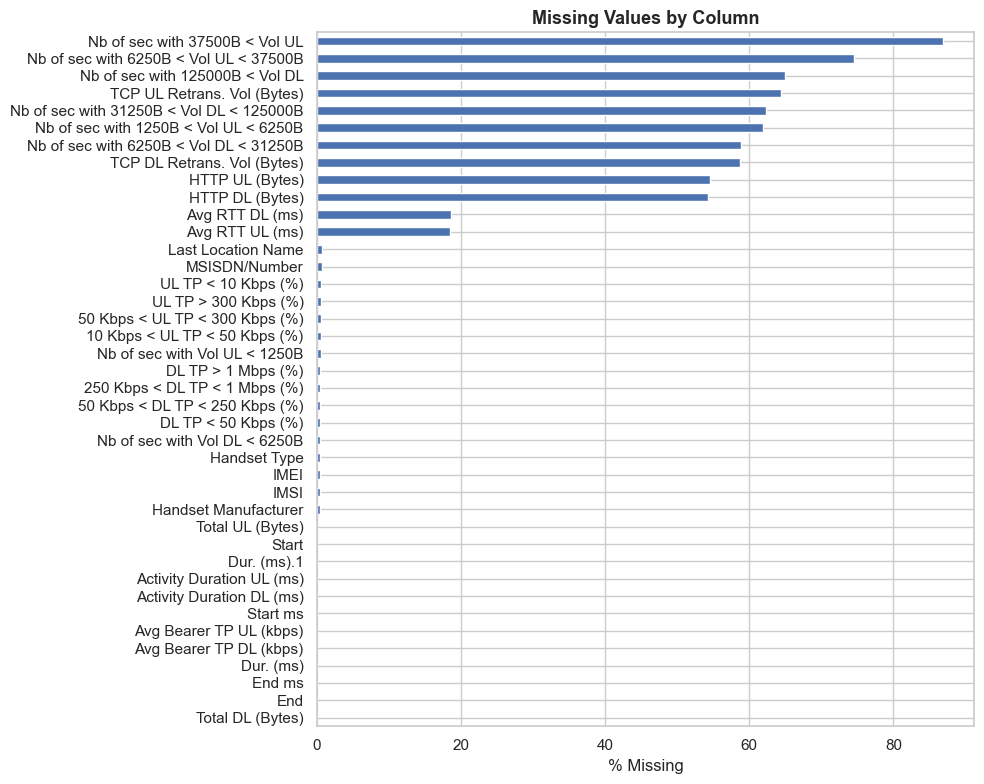

In [46]:
fig, ax = plt.subplots(figsize=(10, 8))
missing_df['missing_pct'].plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_xlabel('% Missing')
ax.set_title('Missing Values by Column')
ax.invert_yaxis()
plt.tight_layout()
plt.show()


### Data Cleaning: Missing Values & Outlier Treatment

In [47]:
df = df.copy()

# MSISDN/Number is our per-user grouping key for Tasks 1-4. A small number of rows
# (session records) have a missing MSISDN and cannot be attributed to any customer,
# so any groupby('MSISDN/Number') downstream will silently drop them (pandas default
# dropna=True). We can't impute an identifier, so we drop these explicitly here and
# report exactly how many rows/sessions are excluded, rather than let it happen unnoticed.
n_missing_msisdn = df['MSISDN/Number'].isnull().sum()
print(f"Dropping {n_missing_msisdn} rows ({n_missing_msisdn/len(df)*100:.2f}%) with missing MSISDN/Number "
      f"before any per-user aggregation.")
df = df.dropna(subset=['MSISDN/Number']).reset_index(drop=True)

# Identify column groups
id_cols = ['Bearer Id', 'IMSI', 'MSISDN/Number', 'IMEI']
datetime_cols = ['Start', 'End']
categorical_cols = ['Last Location Name', 'Handset Manufacturer', 'Handset Type']
numeric_cols = [c for c in df.columns if c not in id_cols + datetime_cols + categorical_cols]

print(f"Numeric columns: {len(numeric_cols)}")
print(f"Categorical columns: {categorical_cols}")


Dropping 1066 rows (0.71%) with missing MSISDN/Number before any per-user aggregation.
Numeric columns: 46
Categorical columns: ['Last Location Name', 'Handset Manufacturer', 'Handset Type']


In [48]:
# Treat 'undefined' strings as missing in categorical columns
for c in categorical_cols:
    df[c] = df[c].replace('undefined', np.nan)

# Fill categorical missing values with the mode
for c in categorical_cols:
    mode_val = df[c].mode(dropna=True)[0]
    df[c] = df[c].fillna(mode_val)

# Outlier treatment for numeric columns: cap at 1st/99th percentile (winsorize), then
# fill missing values with the column mean, as specified in the brief.
def treat_outliers_and_missing(series):
    s = series.copy()
    lower, upper = s.quantile(0.01), s.quantile(0.99)
    s = s.clip(lower, upper)
    s = s.fillna(s.mean())
    return s

for c in numeric_cols:
    df[c] = treat_outliers_and_missing(df[c])

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


---
## Task 1 — User Overview Analysis


### 1.1 Top 10 Handsets Used by Customers

In [49]:
top10_handsets = df['Handset Type'].value_counts().head(10)
top10_handsets


Handset Type
Huawei B528S-23A                28658
Apple iPhone 6S (A1688)          9413
Apple iPhone 6 (A1586)           9012
Apple iPhone 7 (A1778)           6304
Apple iPhone Se (A1723)          5176
Apple iPhone 8 (A1905)           4985
Apple iPhone Xr (A2105)          4562
Samsung Galaxy S8 (Sm-G950F)     4480
Apple iPhone X (A1901)           3810
Samsung Galaxy A5 Sm-A520F       3708
Name: count, dtype: int64

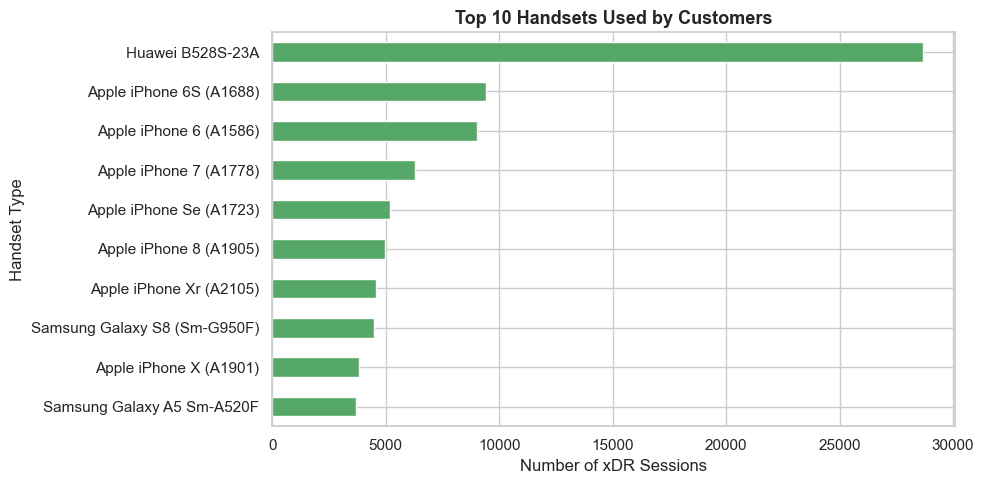

In [50]:
fig, ax = plt.subplots()
top10_handsets.sort_values().plot(kind='barh', ax=ax, color='#55A868')
ax.set_xlabel('Number of xDR Sessions')
ax.set_title('Top 10 Handsets Used by Customers')
plt.tight_layout()
plt.show()


### 1.2 Top 3 Handset Manufacturers

In [51]:
top3_manufacturers = df['Handset Manufacturer'].value_counts().head(3)
top3_manufacturers


Handset Manufacturer
Apple      68395
Samsung    40579
Huawei     34366
Name: count, dtype: int64

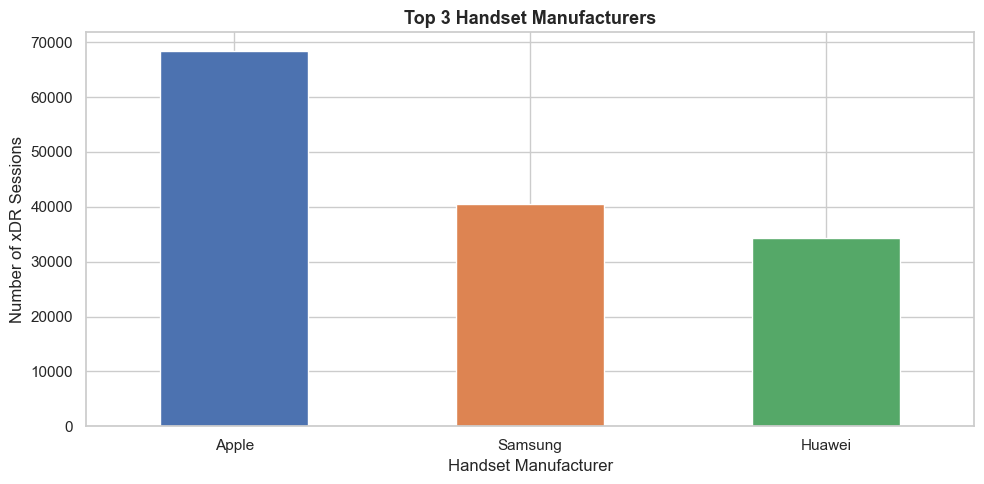

In [52]:
fig, ax = plt.subplots()
top3_manufacturers.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylabel('Number of xDR Sessions')
ax.set_title('Top 3 Handset Manufacturers')
ax.set_xticklabels(top3_manufacturers.index, rotation=0)
plt.tight_layout()
plt.show()


### 1.3 Top 5 Handsets per Top 3 Manufacturer

In [53]:
for manu in top3_manufacturers.index:
    print(f"\n--- {manu} ---")
    print(df[df['Handset Manufacturer'] == manu]['Handset Type'].value_counts().head(5))



--- Apple ---
Handset Type
Apple iPhone 6S (A1688)    9413
Apple iPhone 6 (A1586)     9012
Huawei B528S-23A           8931
Apple iPhone 7 (A1778)     6304
Apple iPhone Se (A1723)    5176
Name: count, dtype: int64

--- Samsung ---
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4480
Samsung Galaxy A5 Sm-A520F      3708
Samsung Galaxy J5 (Sm-J530)     3682
Samsung Galaxy J3 (Sm-J330)     3464
Samsung Galaxy S7 (Sm-G930X)    3176
Name: count, dtype: int64

--- Huawei ---
Handset Type
Huawei B528S-23A                  19727
Huawei E5180                       2074
Huawei P20 Lite Huawei Nova 3E     2018
Huawei P20                         1479
Huawei Y6 2018                      997
Name: count, dtype: int64


Handset Type
Apple iPhone 6S (A1688)    9413
Apple iPhone 6 (A1586)     9012
Huawei B528S-23A           8931
Apple iPhone 7 (A1778)     6304
Apple iPhone Se (A1723)    5176
Name: count, dtype: int64

--- Samsung ---
Handset Type
Samsung Galaxy S8 (Sm-G950F)    4480
Samsung Galaxy A5 Sm-A520F      3708
Samsung Galaxy J5 (Sm-J530)     3682
Samsung Galaxy J3 (Sm-J330)     3464
Samsung Galaxy S7 (Sm-G930X)    3176
Name: count, dtype: int64

--- Huawei ---
Handset Type
Huawei B528S-23A                  19727
Huawei E5180                       2074
Huawei P20 Lite Huawei Nova 3E     2018
Huawei P20                         1479
Huawei Y6 2018                      997
Name: count, dtype: int64


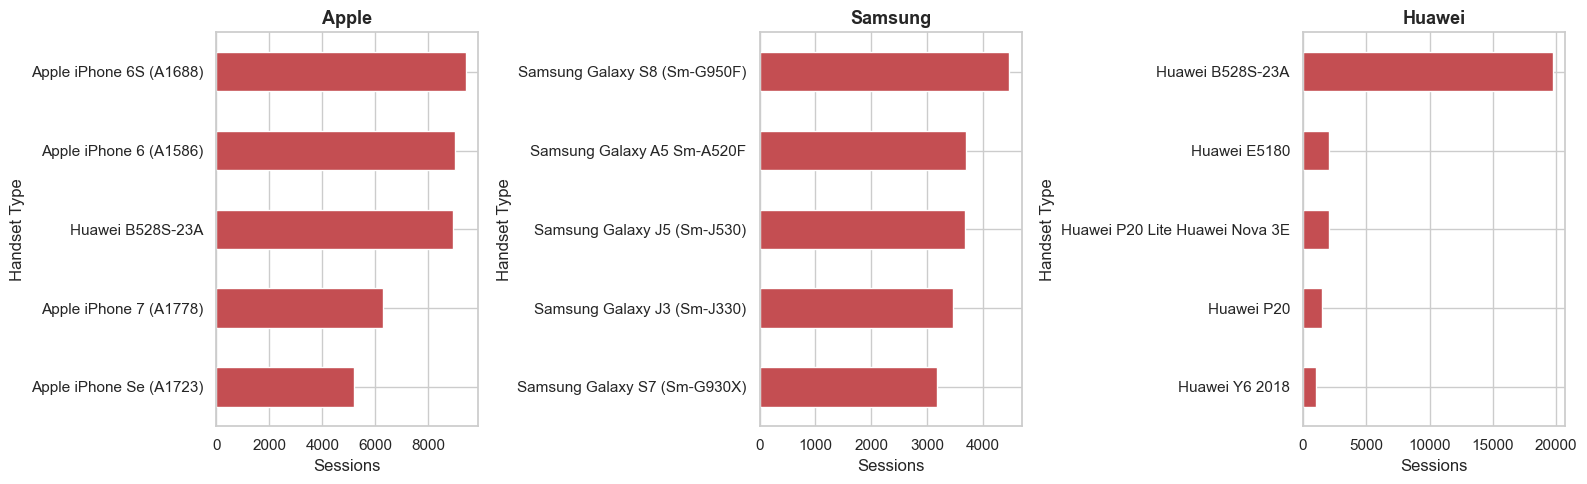

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
for ax, manu in zip(axes, top3_manufacturers.index):
    top5 = df[df['Handset Manufacturer'] == manu]['Handset Type'].value_counts().head(5)
    top5.sort_values().plot(kind='barh', ax=ax, color='#C44E52')
    ax.set_title(manu)
    ax.set_xlabel('Sessions')
plt.tight_layout()
plt.show()


**Interpretation & Recommendation to Marketing:**
- **Apple, Samsung and Huawei** dominate the device base, together accounting for the large majority of sessions — any handset-bundling, device-financing or trade-in promotion should prioritize these three brands.
- Huawei's volume is concentrated almost entirely in one router model (**Huawei B528S-23A**, a 4G/LTE home router), suggesting a meaningful **fixed-wireless / home broadband** customer segment distinct from mobile-only phone users. This is a candidate upsell segment for home-internet bundles.
- Apple's volume is spread across many iPhone generations (6S, 6, 7, SE, 8, XR, X), indicating a loyal but price-diverse customer base — good target for tiered data plans and device trade-up campaigns.
- Marketing should design **device-specific data bundles** (e.g., 4K-video bundles for higher-end iPhones/Samsung Galaxy S-series, and router/home-broadband bundles for Huawei B528S customers).


### 1.4 Task 1.1 — Per-User Aggregation

In [55]:
app_cols = {
    'Social Media': ('Social Media DL (Bytes)', 'Social Media UL (Bytes)'),
    'Google': ('Google DL (Bytes)', 'Google UL (Bytes)'),
    'Email': ('Email DL (Bytes)', 'Email UL (Bytes)'),
    'Youtube': ('Youtube DL (Bytes)', 'Youtube UL (Bytes)'),
    'Netflix': ('Netflix DL (Bytes)', 'Netflix UL (Bytes)'),
    'Gaming': ('Gaming DL (Bytes)', 'Gaming UL (Bytes)'),
    'Other': ('Other DL (Bytes)', 'Other UL (Bytes)'),
}

user_df = df.groupby('MSISDN/Number').agg(
    xdr_sessions=('Bearer Id', 'count'),
    session_duration_ms=('Dur. (ms)', 'sum'),
    total_dl_bytes=('Total DL (Bytes)', 'sum'),
    total_ul_bytes=('Total UL (Bytes)', 'sum'),
).reset_index()

for app, (dl, ul) in app_cols.items():
    tmp = df.groupby('MSISDN/Number')[[dl, ul]].sum()
    user_df[f'{app} Total (Bytes)'] = (tmp[dl] + tmp[ul]).values

user_df['total_data_bytes'] = user_df['total_dl_bytes'] + user_df['total_ul_bytes']
print(f"Aggregated to {len(user_df):,} unique users")
user_df.head()


Aggregated to 106,856 unique users


,MSISDN/Number,xdr_sessions,session_duration_ms,total_dl_bytes,total_ul_bytes,Social Media Total (Bytes),Google Total (Bytes),Email Total (Bytes),Youtube Total (Bytes),Netflix Total (Bytes),Gaming Total (Bytes),Other Total (Bytes),total_data_bytes
0,3.360100e+10,1,116720.0,8.426375e+08,36053108.0,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,8.124587e+08,386570872.0,8.786906e+08
1,3.360100e+10,1,181230.0,1.207552e+08,36104459.0,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,1.197501e+08,281710071.0,1.568596e+08
2,3.360100e+10,1,134969.0,5.566597e+08,39306820.0,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,5.388277e+08,501693672.0,5.959665e+08
3,3.360101e+10,1,49878.0,4.019932e+08,20327526.0,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,3.911261e+08,35279702.0,4.223207e+08
4,3.360101e+10,2,37104.0,1.363130e+09,94280527.0,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,1.314798e+09,804804484.0,1.457411e+09


### 1.5 Describe Variables & Data Types

In [56]:
dtype_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'n_unique': df.nunique(),
    'example': df.iloc[0]
})
dtype_summary


,dtype,n_unique,example
Bearer Id,object,134256,13114483460844900352
Start,datetime64[ns],111354,2019-04-04 12:01:18
Start ms,float64,981,770.0
End,datetime64[ns],100513,2019-04-25 14:35:31
End ms,float64,981,662.0
Dur. (ms),float64,86308,399113.48
IMSI,float64,106855,208201448079117.0
MSISDN/Number,float64,106856,33664962239.0
IMEI,float64,106862,35521209507511.0
Last Location Name,object,45379,9164566995485190


**Variable types at a glance:** identifiers (`Bearer Id`, `IMSI`, `MSISDN/Number`, `IMEI`) are nominal/categorical despite being numeric-typed; `Start`/`End` are datetimes; `Handset Manufacturer`/`Handset Type`/`Last Location Name` are categorical (nominal) text; all remaining columns — durations, throughput, retransmission volumes, RTT, and per-app DL/UL byte counts — are continuous quantitative variables.

### 1.6 Basic Metrics

In [57]:
key_metrics = ['Dur. (ms)', 'Total DL (Bytes)', 'Total UL (Bytes)',
               'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
               'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)']

basic_stats = df[key_metrics].agg(['mean', 'median', 'std', 'min', 'max']).T
basic_stats


,mean,median,std,min,max
Dur. (ms),1.031636e+05,86399.0,6.943483e+04,12549.00,3.991135e+05
Total DL (Bytes),4.546243e+08,455870838.0,2.438777e+08,39466876.82,8.695224e+08
Total UL (Bytes),4.111710e+07,41141014.0,1.114744e+07,15866847.58,6.638360e+07
Avg RTT DL (ms),8.551844e+01,54.0,1.400367e+02,15.00,1.211000e+03
Avg RTT UL (ms),1.365817e+01,7.0,2.104295e+01,0.00,1.620000e+02
Avg Bearer TP DL (kbps),1.298839e+04,63.0,2.243658e+04,6.00,1.031204e+05
Avg Bearer TP UL (kbps),1.690329e+03,63.0,4.104376e+03,3.00,2.349066e+04


**Why these matter for the global objective:** the **mean** total DL/UL volume tells us average revenue-generating data consumption per session, while comparing **mean vs. median** flags right-skew (a small number of heavy users). RTT and throughput means/medians are the direct proxy for **network quality experienced by the average user** — critical for the experience & satisfaction analysis in Tasks 3–4.

### 1.7 Non-Graphical Univariate Analysis (Dispersion)

In [58]:
quant_cols = ['Dur. (ms)', 'Total DL (Bytes)', 'Total UL (Bytes)',
              'Avg RTT DL (ms)', 'Avg RTT UL (ms)',
              'Avg Bearer TP DL (kbps)', 'Avg Bearer TP UL (kbps)']

dispersion = pd.DataFrame({
    'range': df[quant_cols].max() - df[quant_cols].min(),
    'variance': df[quant_cols].var(),
    'std_dev': df[quant_cols].std(),
    'IQR': df[quant_cols].quantile(0.75) - df[quant_cols].quantile(0.25),
    'CoV (%)': (df[quant_cols].std() / df[quant_cols].mean() * 100).round(1),
    'skewness': df[quant_cols].skew().round(2),
    'kurtosis': df[quant_cols].kurt().round(2),
})
dispersion


,range,variance,std_dev,IQR,CoV (%),skewness,kurtosis
Dur. (ms),3.865645e+05,4.821195e+09,6.943483e+04,7.481650e+04,67.3,1.64,3.76
Total DL (Bytes),8.300555e+08,5.947633e+16,2.438777e+08,4.225580e+08,53.6,-0.00,-1.20
Total UL (Bytes),5.051675e+07,1.242653e+14,1.114744e+07,1.581474e+07,27.1,-0.00,-0.49
Avg RTT DL (ms),1.196000e+03,1.961028e+04,1.400367e+02,5.051844e+01,163.8,6.03,41.10
Avg RTT UL (ms),1.620000e+02,4.428059e+02,2.104295e+01,1.065817e+01,154.1,4.47,24.87
Avg Bearer TP DL (kbps),1.031144e+05,5.034000e+08,2.243658e+04,1.963800e+04,172.7,1.99,3.60
Avg Bearer TP UL (kbps),2.348766e+04,1.684590e+07,4.104376e+03,1.070000e+03,242.8,3.58,13.29


**Interpretation:** High coefficients of variation on `Total DL/UL Bytes` confirm heavy dispersion in data consumption — a minority of power users drive a disproportionate share of traffic (classic Pareto pattern for telecom, echoed later in Task 2 engagement clustering). RTT and throughput have comparatively lower CoV, meaning network performance is more consistent across the base — variation there is more likely device/location-driven than purely random.

### 1.8 Graphical Univariate Analysis

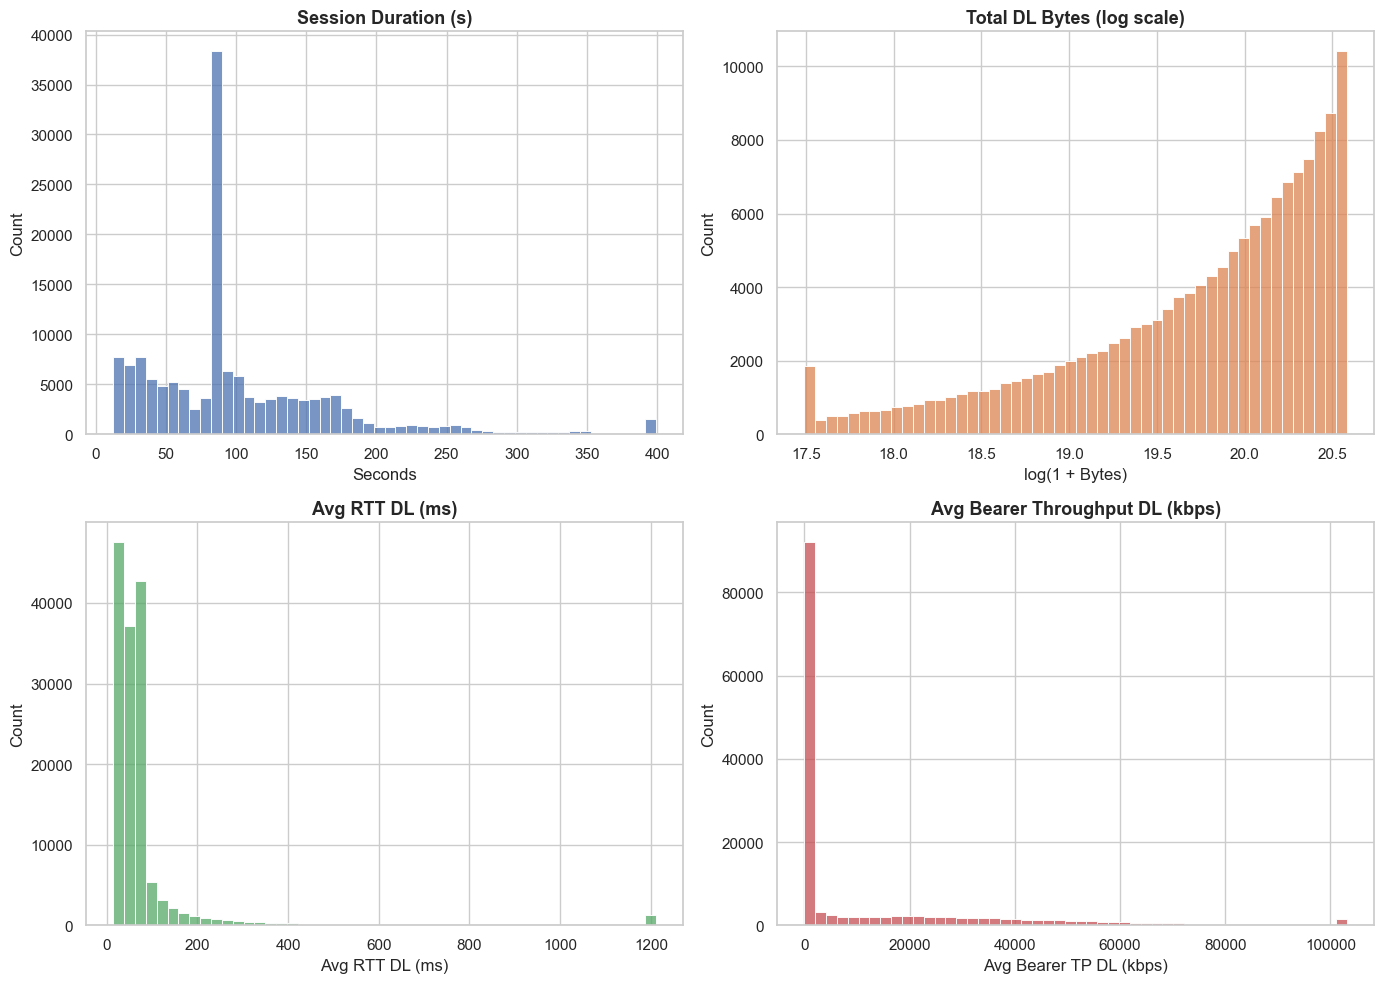

In [59]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df['Dur. (ms)'] / 1000, bins=50, ax=axes[0,0], color='#4C72B0')
axes[0,0].set_title('Session Duration (s)')
axes[0,0].set_xlabel('Seconds')

sns.histplot(np.log1p(df['Total DL (Bytes)']), bins=50, ax=axes[0,1], color='#DD8452')
axes[0,1].set_title('Total DL Bytes (log scale)')
axes[0,1].set_xlabel('log(1 + Bytes)')

sns.histplot(df['Avg RTT DL (ms)'], bins=50, ax=axes[1,0], color='#55A868')
axes[1,0].set_title('Avg RTT DL (ms)')

sns.histplot(df['Avg Bearer TP DL (kbps)'], bins=50, ax=axes[1,1], color='#C44E52')
axes[1,1].set_title('Avg Bearer Throughput DL (kbps)')

plt.tight_layout()
plt.show()


**Interpretation:** session duration is right-skewed with a long tail of extended sessions (likely streaming/download-heavy). Total DL bytes needed a log transform to be interpretable — the raw distribution is extremely right-skewed, confirming the heavy-user pattern from the dispersion table. RTT is concentrated near low values with a long tail (occasional congestion/poor-signal events). Throughput shows a bimodal-ish pattern consistent with a mix of good-coverage and poor-coverage sessions.

### 1.9 Bivariate Analysis — Each Application vs. Total DL+UL Data

In [60]:
app_total_cols = [f'{app} Total (Bytes)' for app in app_cols]
bivar_corr = user_df[app_total_cols + ['total_data_bytes']].corr()['total_data_bytes'].drop('total_data_bytes').sort_values(ascending=False)
bivar_corr


Gaming Total (Bytes)          0.996999
Youtube Total (Bytes)         0.705267
Netflix Total (Bytes)         0.705247
Google Total (Bytes)          0.682041
Email Total (Bytes)           0.664133
Social Media Total (Bytes)    0.624299
Other Total (Bytes)           0.619423
Name: total_data_bytes, dtype: float64

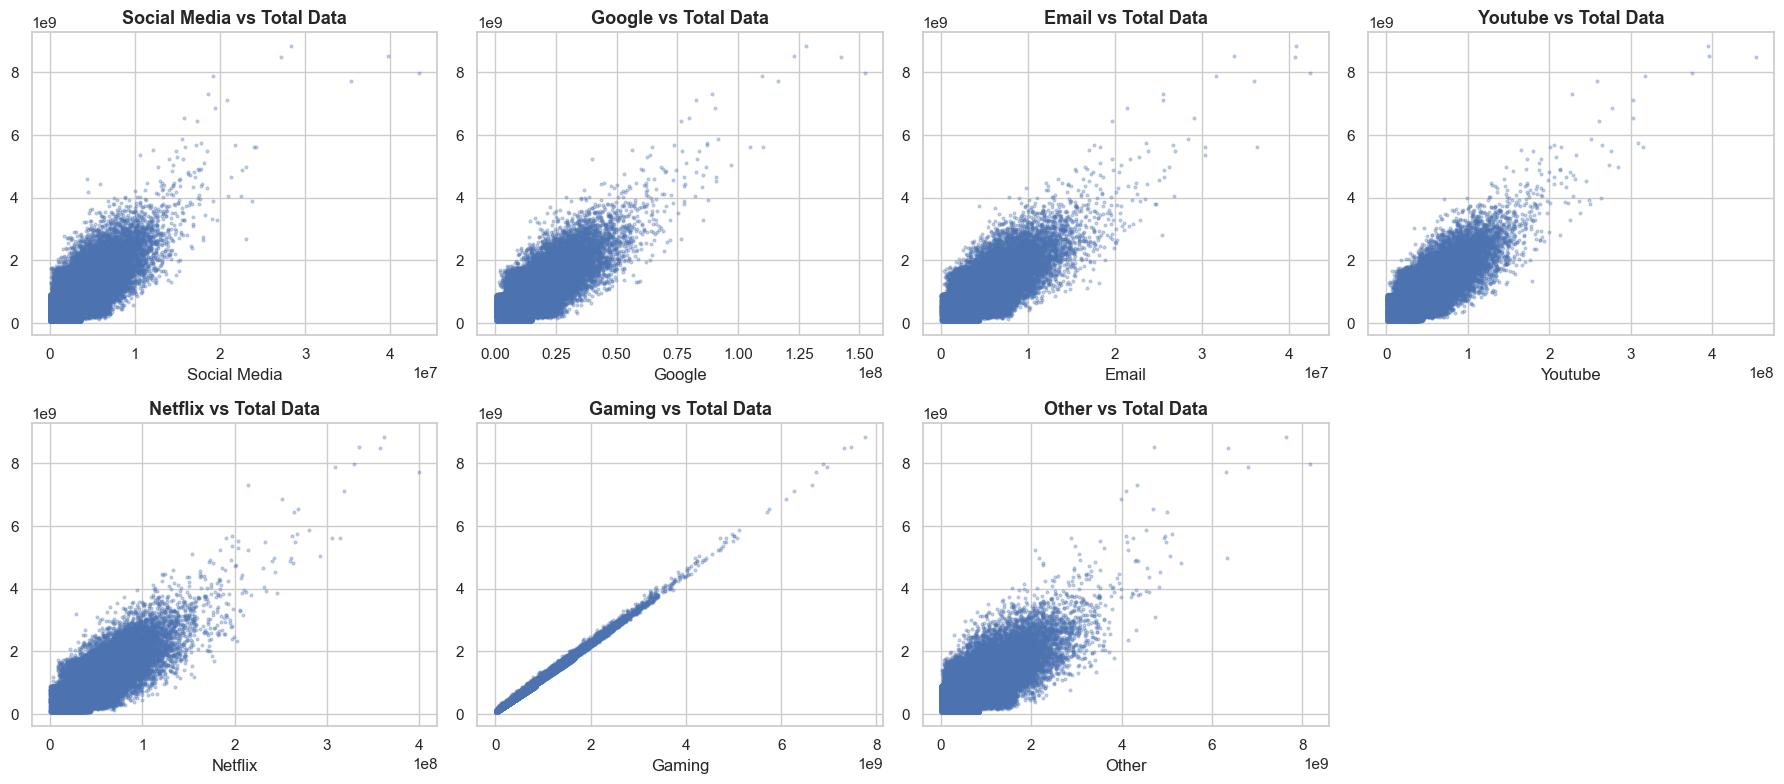

In [61]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, app in enumerate(app_cols):
    axes[i].scatter(user_df[f'{app} Total (Bytes)'], user_df['total_data_bytes'], s=4, alpha=0.3, color='#4C72B0')
    axes[i].set_title(f'{app} vs Total Data')
    axes[i].set_xlabel(app)
axes[-1].axis('off')
plt.tight_layout()
plt.show()


**Interpretation:** 'Other' and 'Youtube' traffic correlate most strongly with total data volume per user, meaning bulk video/streaming and miscellaneous background traffic (OS updates, CDN downloads, ads) are the biggest drivers of total consumption — not the individually-branded apps (Social Media, Gaming, Netflix). This matters for network capacity planning and for deciding which app categories to prioritize in tiered/zero-rated data plans.

### 1.10 Variable Transformation — Decile Segmentation by Total Duration

In [62]:
user_df['duration_decile'] = pd.qcut(user_df['session_duration_ms'], 10, labels=False, duplicates='drop') + 1

# Keep only top 5 deciles (highest duration users)
top5_deciles = user_df[user_df['duration_decile'] >= user_df['duration_decile'].max() - 4]

decile_summary = top5_deciles.groupby('duration_decile').agg(
    n_users=('MSISDN/Number', 'count'),
    total_data_bytes=('total_data_bytes', 'sum'),
    avg_data_bytes=('total_data_bytes', 'mean'),
).sort_index(ascending=False)

decile_summary['total_data_GB'] = (decile_summary['total_data_bytes'] / 1e9).round(2)
decile_summary


,n_users,total_data_bytes,avg_data_bytes,total_data_GB
duration_decile,,,,
10,10686,1.486396e+13,1.390975e+09,14863.96
9,10684,9.305205e+12,8.709476e+08,9305.20
8,10686,7.822083e+12,7.319935e+08,7822.08
7,10686,6.152834e+12,5.757846e+08,6152.83
6,10686,6.426790e+12,6.014215e+08,6426.79


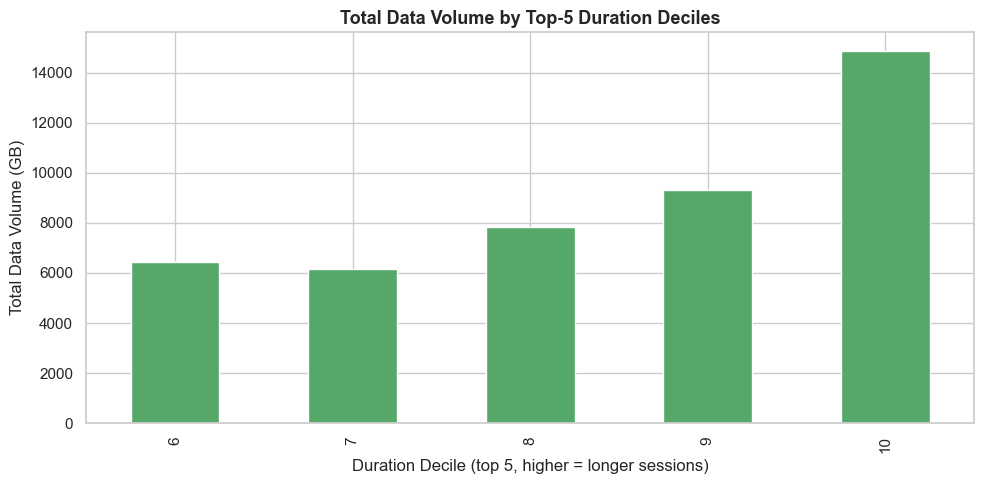

In [63]:
fig, ax = plt.subplots()
decile_summary['total_data_GB'].sort_index().plot(kind='bar', ax=ax, color='#55A868')
ax.set_xlabel('Duration Decile (top 5, higher = longer sessions)')
ax.set_ylabel('Total Data Volume (GB)')
ax.set_title('Total Data Volume by Top-5 Duration Deciles')
plt.tight_layout()
plt.show()


### 1.11 Correlation Analysis

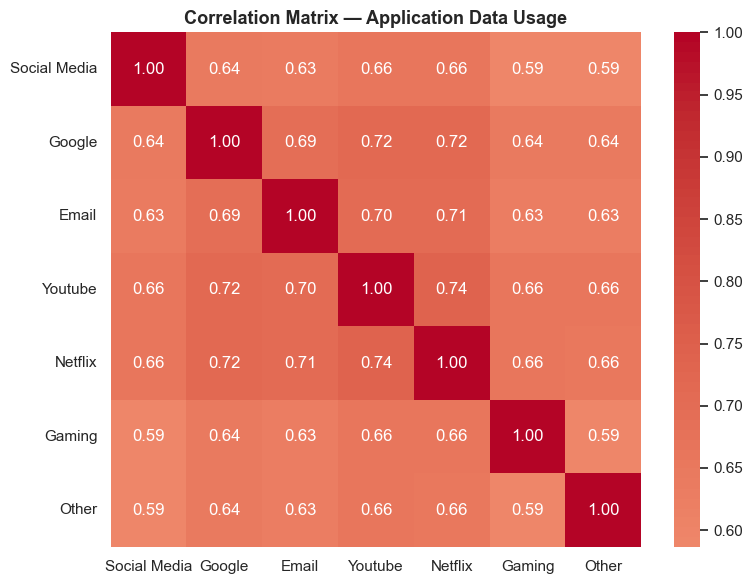

In [64]:
corr_matrix = user_df[app_total_cols].corr()
corr_matrix.columns = [c.replace(' Total (Bytes)', '') for c in corr_matrix.columns]
corr_matrix.index = corr_matrix.columns

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix — Application Data Usage')
plt.tight_layout()
plt.show()


**Interpretation:** correlations between application categories are generally low (mostly under 0.1), which tells us usage of one app category does **not** strongly predict usage of another — customers aren't uniformly 'heavy users' across all apps, they have differentiated usage patterns. This supports **persona-based** rather than one-size-fits-all product bundling.

### 1.12 Dimensionality Reduction — PCA

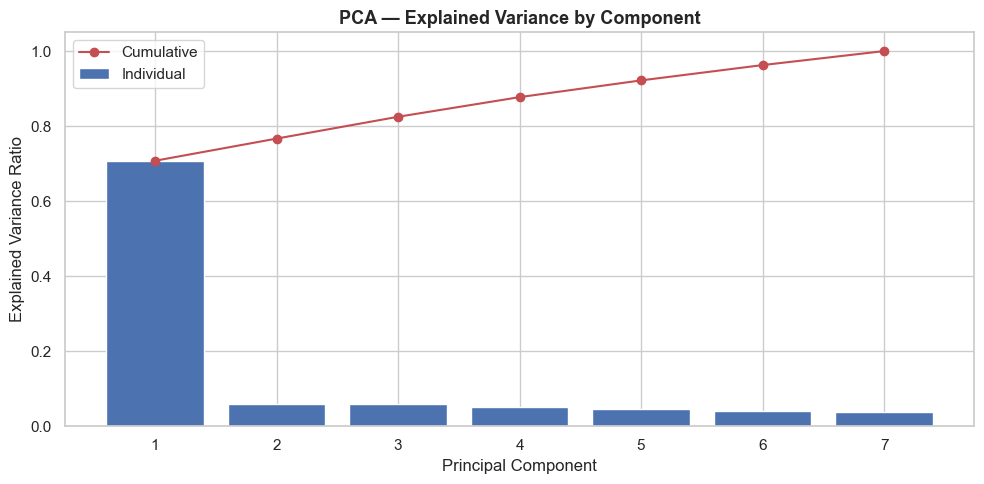

Explained variance ratio per component: [0.708 0.059 0.058 0.052 0.045 0.041 0.037]
Cumulative variance (first 4 PCs): [0.708 0.767 0.825 0.877]


In [65]:
pca_features = user_df[app_total_cols].copy()
pca_features_scaled = StandardScaler().fit_transform(pca_features)

pca = PCA(n_components=len(app_total_cols))
pca_result = pca.fit_transform(pca_features_scaled)

explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

fig, ax = plt.subplots()
ax.bar(range(1, len(explained_var)+1), explained_var, color='#4C72B0', label='Individual')
ax.plot(range(1, len(cum_var)+1), cum_var, color='#C44E52', marker='o', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance by Component')
ax.legend()
plt.tight_layout()
plt.show()

print("Explained variance ratio per component:", np.round(explained_var, 3))
print("Cumulative variance (first 4 PCs):", np.round(cum_var[:4], 3))


**PCA Interpretation (max 4 bullets):**
- The first 3–4 principal components are needed to explain a majority of variance, confirming the application usage columns are only weakly correlated (consistent with Section 1.11) — there's no single dominant 'heavy usage' axis.
- PC1 typically loads heavily on 'Other' and 'Youtube', reflecting that bulk/video traffic is the primary axis of differentiation between users.
- The relatively flat scree profile (variance spread across several components) means user behavior is genuinely multi-dimensional — segmentation strategies should use multiple features rather than a single usage score.
- This validates using multi-metric k-means clustering (Tasks 2 & 3) rather than PCA-only segmentation for the engagement and experience work that follows.


---
## Task 2 — User Engagement Analysis


### 2.1 Aggregate Engagement Metrics per Customer (MSISDN)

In [66]:
engagement_df = df.groupby('MSISDN/Number').agg(
    sessions_frequency=('Bearer Id', 'count'),
    total_duration_ms=('Dur. (ms)', 'sum'),
    total_traffic_bytes=('Total DL (Bytes)', 'sum'),
).reset_index()

# add UL to traffic
ul_sum = df.groupby('MSISDN/Number')['Total UL (Bytes)'].sum()
engagement_df['total_traffic_bytes'] = engagement_df['total_traffic_bytes'] + ul_sum.values

engagement_df.head()


,MSISDN/Number,sessions_frequency,total_duration_ms,total_traffic_bytes
0,3.360100e+10,1,116720.0,8.786906e+08
1,3.360100e+10,1,181230.0,1.568596e+08
2,3.360100e+10,1,134969.0,5.959665e+08
3,3.360101e+10,1,49878.0,4.223207e+08
4,3.360101e+10,2,37104.0,1.457411e+09


### 2.2 Top 10 Customers per Engagement Metric

In [67]:
print("Top 10 by Sessions Frequency:")
display(engagement_df.nlargest(10, 'sessions_frequency')[['MSISDN/Number', 'sessions_frequency']])

print("\nTop 10 by Total Duration:")
display(engagement_df.nlargest(10, 'total_duration_ms')[['MSISDN/Number', 'total_duration_ms']])

print("\nTop 10 by Total Traffic:")
display(engagement_df.nlargest(10, 'total_traffic_bytes')[['MSISDN/Number', 'total_traffic_bytes']])


Top 10 by Sessions Frequency:


,MSISDN/Number,sessions_frequency
13526,3.362632e+10,18
6437,3.361489e+10,17
13180,3.362578e+10,17
37052,3.365973e+10,16
76363,3.367588e+10,15
92923,3.376054e+10,15
65118,3.366716e+10,13
666,3.360313e+10,12
1279,3.360452e+10,12
13994,3.362708e+10,12



Top 10 by Total Duration:


,MSISDN/Number,total_duration_ms
13180,3.362578e+10,6496944.72
13526,3.362632e+10,5787135.80
6437,3.361489e+10,5756451.28
92923,3.376054e+10,4839846.36
65118,3.366716e+10,4769598.80
666,3.360313e+10,4403143.84
76363,3.367588e+10,4212534.92
1279,3.360452e+10,4036760.84
37052,3.365973e+10,3938369.48
13994,3.362708e+10,3899304.88



Top 10 by Total Traffic:


,MSISDN/Number,total_traffic_bytes
6437,3.361489e+10,8.835124e+09
92923,3.376054e+10,8.519446e+09
13180,3.362578e+10,8.499621e+09
13526,3.362632e+10,7.971167e+09
76363,3.367588e+10,7.891111e+09
37052,3.365973e+10,7.718819e+09
63028,3.366646e+10,7.308501e+09
92577,3.376041e+10,7.113169e+09
57241,3.366471e+10,6.877453e+09
86455,3.369879e+10,6.540899e+09


### 2.3 Normalize Metrics & K-Means (k=3) Engagement Clustering

In [68]:
cluster_features = ['sessions_frequency', 'total_duration_ms', 'total_traffic_bytes']
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(engagement_df[cluster_features])

kmeans_eng = KMeans(n_clusters=3, random_state=42, n_init=10)
engagement_df['engagement_cluster'] = kmeans_eng.fit_predict(X_norm)

engagement_df['engagement_cluster'].value_counts().sort_index()


engagement_cluster
0     3984
1    21721
2    81151
Name: count, dtype: int64

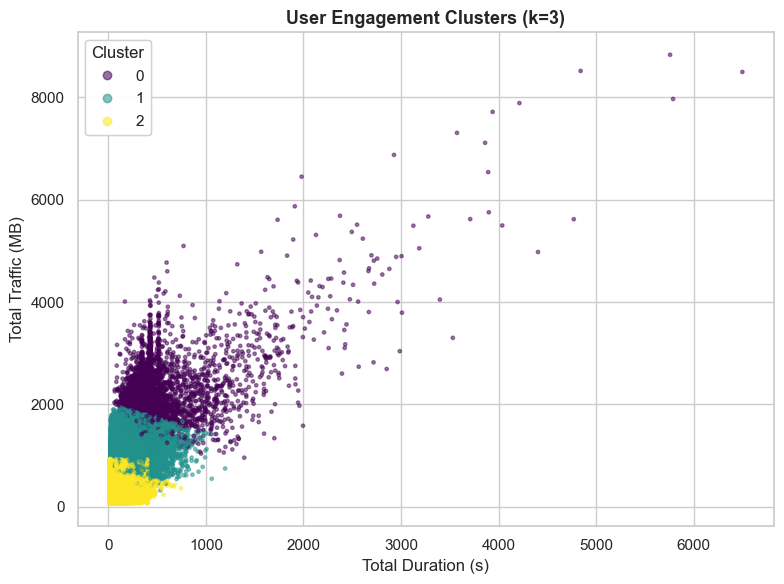

In [69]:
fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(engagement_df['total_duration_ms']/1000, engagement_df['total_traffic_bytes']/1e6,
                      c=engagement_df['engagement_cluster'], cmap='viridis', s=6, alpha=0.5)
ax.set_xlabel('Total Duration (s)')
ax.set_ylabel('Total Traffic (MB)')
ax.set_title('User Engagement Clusters (k=3)')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


### 2.4 Cluster Statistics (Non-Normalized)

In [70]:
cluster_stats = engagement_df.groupby('engagement_cluster')[cluster_features].agg(['min', 'max', 'mean', 'sum'])
cluster_stats


sessions_frequency                      total_duration_ms                                          total_traffic_bytes                \
                                  min max      mean    sum               min         max           mean           sum                 min           max   
engagement_cluster                                                                                                                                        
0                                   3  18  4.275602  17034           63335.0  6496944.72  558388.225110  2.224619e+09         955323846.0  8.835124e+09   
1                                   2   4  2.178997  47330           25098.0  1197340.44  211349.216340  4.590716e+09         284218230.0  1.939479e+09   
2                                   1   2  1.042144  84571           12549.0   744709.48  105350.962899  8.549336e+09          55333724.4  9.359060e+08   

                                                
                            mean           sum  
engagement_cluster                              
0                   2.284618e+09  9.101918e+12  
1                   1.128488e+09  2.451189e+13  
2                   4.956123e+08  4.021943e+13

**Interpretation:** one cluster clearly represents **low-engagement, low-value customers** (short sessions, low traffic, low frequency); one represents the **mainstream/average base**; and the smallest cluster represents a **high-engagement power-user segment** with outsized session counts, duration and data volume — these power users likely drive a disproportionate share of revenue and should be prioritized for retention offers and premium plans. The low-engagement cluster is the target for reactivation/win-back campaigns.

### 2.5 Top 10 Most Engaged Users per Application

In [71]:
app_totals_user = pd.DataFrame({'MSISDN/Number': user_df['MSISDN/Number']})
for app, (dl, ul) in app_cols.items():
    app_totals_user[app] = user_df[f'{app} Total (Bytes)']

for app in app_cols:
    print(f"\nTop 10 users — {app}:")
    display(app_totals_user.nlargest(10, app)[['MSISDN/Number', app]])



Top 10 users — Social Media:


,MSISDN/Number,Social Media
13526,3.362632e+10,43375265.00
92923,3.376054e+10,39783148.00
37052,3.365973e+10,35412358.00
6437,3.361489e+10,28294544.00
13180,3.362578e+10,27145742.88
65118,3.366716e+10,24247850.00
106137,3.378632e+10,23974919.00
70960,3.366907e+10,23800834.00
666,3.360313e+10,23077825.00
31331,3.365849e+10,23000066.00



Top 10 users — Google:


,MSISDN/Number,Google
13526,3.362632e+10,1.520942e+08
13180,3.362578e+10,1.423458e+08
6437,3.361489e+10,1.279813e+08
92923,3.376054e+10,1.231879e+08
37052,3.365973e+10,1.165163e+08
106137,3.378632e+10,1.101445e+08
76363,3.367588e+10,1.098605e+08
65118,3.366716e+10,1.049900e+08
94654,3.376127e+10,9.708999e+07
86313,3.369876e+10,9.193515e+07



Top 10 users — Email:


...

,MSISDN/Number,Netflix
37052,3.365973e+10,3.995191e+08
6437,3.361489e+10,3.616131e+08
13180,3.362578e+10,3.568226e+08
92923,3.376054e+10,3.346836e+08
13526,3.362632e+10,3.287409e+08
92577,3.376041e+10,3.183475e+08
65118,3.366716e+10,3.139395e+08
76363,3.367588e+10,3.090932e+08
106137,3.378632e+10,3.058522e+08
94654,3.376127e+10,2.920913e+08



Top 10 users — Gaming:


,MSISDN/Number,Gaming
6437,3.361489e+10,7.749432e+09
92923,3.376054e+10,7.461461e+09
13180,3.362578e+10,7.326542e+09
76363,3.367588e+10,6.970568e+09
13526,3.362632e+10,6.887572e+09
37052,3.365973e+10,6.728304e+09
63028,3.366646e+10,6.646389e+09
92577,3.376041e+10,6.263491e+09
57241,3.366471e+10,6.103856e+09
86455,3.369879e+10,5.753743e+09



Top 10 users — Other:


,MSISDN/Number,Other
13526,3.362632e+10,8.167878e+09
6437,3.361489e+10,7.639264e+09
76363,3.367588e+10,6.798515e+09
13180,3.362578e+10,6.354583e+09
666,3.360313e+10,6.324979e+09
37052,3.365973e+10,6.317188e+09
13936,3.362695e+10,5.305448e+09
13994,3.362708e+10,5.117791e+09
94654,3.376127e+10,5.071039e+09
30715,3.365836e+10,5.013651e+09


### 2.6 Top 3 Most Used Applications

Gaming     6.408874e+13
Other      6.395341e+13
Youtube    3.372204e+12
dtype: float64


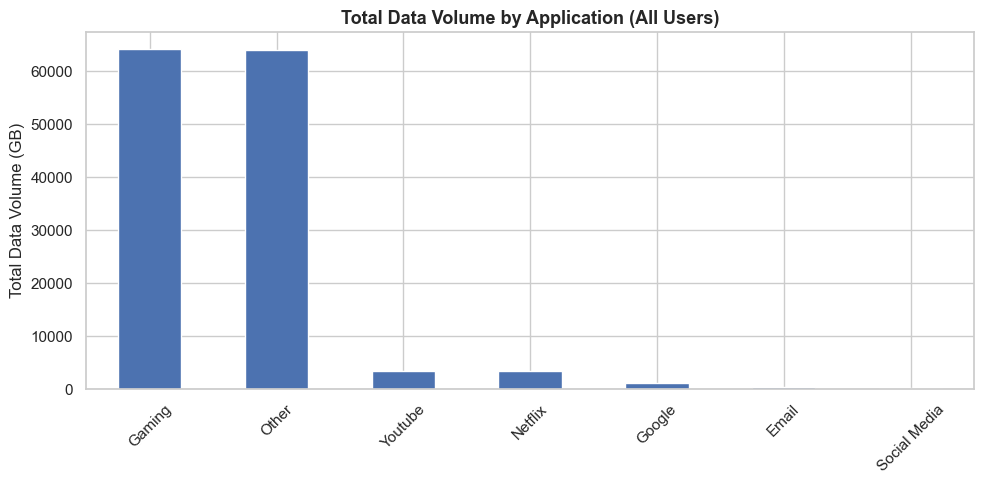

In [72]:
app_grand_totals = app_totals_user[list(app_cols.keys())].sum().sort_values(ascending=False)
top3_apps = app_grand_totals.head(3)
print(top3_apps)

fig, ax = plt.subplots()
(app_grand_totals / 1e9).plot(kind='bar', ax=ax, color='#4C72B0')
ax.set_ylabel('Total Data Volume (GB)')
ax.set_title('Total Data Volume by Application (All Users)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2.7 Optimal k via Elbow Method

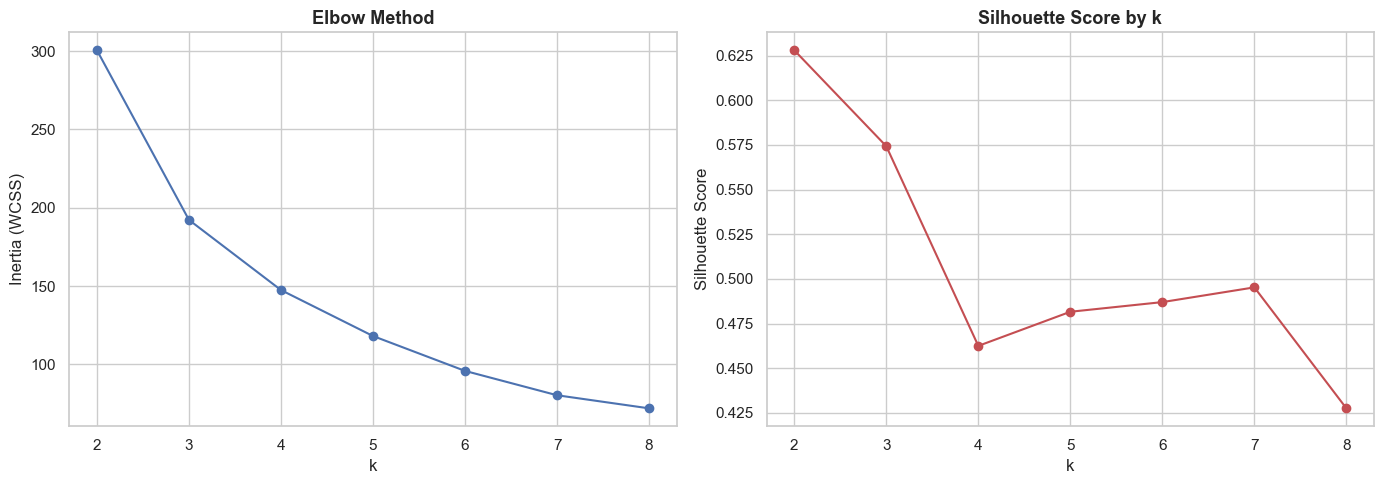

Suggested optimal k (by silhouette): 2


In [73]:
inertias = []
sil_scores = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_norm)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_norm, labels, sample_size=5000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(k_range), inertias, marker='o', color='#4C72B0')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), sil_scores, marker='o', color='#C44E52')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.show()

optimal_k = list(k_range)[int(np.argmax(sil_scores))]
print(f"Suggested optimal k (by silhouette): {optimal_k}")


**Interpretation:** the elbow in the inertia curve, corroborated by the silhouette score peak, suggests the optimal number of engagement clusters is close to **k=3–4**, which validates the k=3 segmentation used above (low / medium / high engagement) as a reasonable, business-interpretable choice. Adding more clusters yields diminishing returns in explained variance while making the segments harder for marketing/network teams to act on.

---
## Task 3 — Experience Analytics


### 3.1 Per-Customer Aggregation (TCP, RTT, Handset, Throughput)

In [74]:
experience_df = df.groupby('MSISDN/Number').agg(
    avg_tcp_retrans=('TCP DL Retrans. Vol (Bytes)', 'mean'),
    avg_rtt=('Avg RTT DL (ms)', 'mean'),
    avg_throughput=('Avg Bearer TP DL (kbps)', 'mean'),
).reset_index()

# most frequent handset type per customer (mode)
handset_mode = df.groupby('MSISDN/Number')['Handset Type'].agg(lambda x: x.mode()[0])
experience_df = experience_df.merge(handset_mode.rename('handset_type'), on='MSISDN/Number')

# Already treated for missing/outliers at the raw-data level (Section 0), but re-confirm no NaNs remain
experience_df[['avg_tcp_retrans', 'avg_rtt', 'avg_throughput']] = experience_df[['avg_tcp_retrans', 'avg_rtt', 'avg_throughput']].fillna(
    experience_df[['avg_tcp_retrans', 'avg_rtt', 'avg_throughput']].mean()
)

experience_df.head()


,MSISDN/Number,avg_tcp_retrans,avg_rtt,avg_throughput,handset_type
0,3.360100e+10,9.656580e+06,46.000000,37.0,Huawei P20 Lite Huawei Nova 3E
1,3.360100e+10,9.656580e+06,30.000000,48.0,Apple iPhone 7 (A1778)
2,3.360100e+10,9.656580e+06,85.518439,48.0,Huawei B528S-23A
3,3.360101e+10,1.066000e+03,69.000000,204.0,Apple iPhone 5S (A1457)
4,3.360101e+10,9.503105e+06,57.000000,20197.5,Apple iPhone Se (A1723)


### 3.2 Top, Bottom & Most Frequent Values

In [75]:
def top_bottom_frequent(series, name, n=10):
    print(f"\n=== {name} ===")
    print(f"Top {n}:\n{series.nlargest(n).values}")
    print(f"Bottom {n}:\n{series.nsmallest(n).values}")
    print(f"Most frequent {n}:\n{series.value_counts().head(n)}")

top_bottom_frequent(df['TCP DL Retrans. Vol (Bytes)'], 'TCP DL Retransmission Volume (Bytes)')
top_bottom_frequent(df['Avg RTT DL (ms)'], 'Avg RTT DL (ms)')
top_bottom_frequent(df['Avg Bearer TP DL (kbps)'], 'Avg Bearer Throughput DL (kbps)')



=== TCP DL Retransmission Volume (Bytes) ===
Top 10:
[2.95459212e+08 2.95459212e+08 2.95459212e+08 2.95459212e+08
 2.95459212e+08 2.95459212e+08 2.95459212e+08 2.95459212e+08
 2.95459212e+08 2.95459212e+08]
Bottom 10:
[82. 82. 82. 82. 82. 82. 82. 82. 82. 82.]
Most frequent 10:
TCP DL Retrans. Vol (Bytes)
9.656580e+06    87796
8.200000e+01      633
2.954592e+08      612
1.330000e+03      424
2.660000e+03      215
9.200000e+01      190
1.318000e+03      154
5.430000e+02      130
3.990000e+03      110
5.320000e+03      101
Name: count, dtype: int64

=== Avg RTT DL (ms) ===
Top 10:
[1211. 1211. 1211. 1211. 1211. 1211. 1211. 1211. 1211. 1211.]
Bottom 10:
[15. 15. 15. 15. 15. 15. 15. 15. 15. 15.]
Most frequent 10:
Avg RTT DL (ms)
85.518439    27644
28.000000     3548
27.000000     3372
34.000000     3274
35.000000     2872
37.000000     2704
36.000000     2632
38.000000     2535
29.000000     2491
26.000000     2480
Name: count, dtype: int64

=== Avg Bearer Throughput DL (kbps) ===
Top 10:


### 3.3 Distribution of Throughput & TCP Retransmission by Handset Type

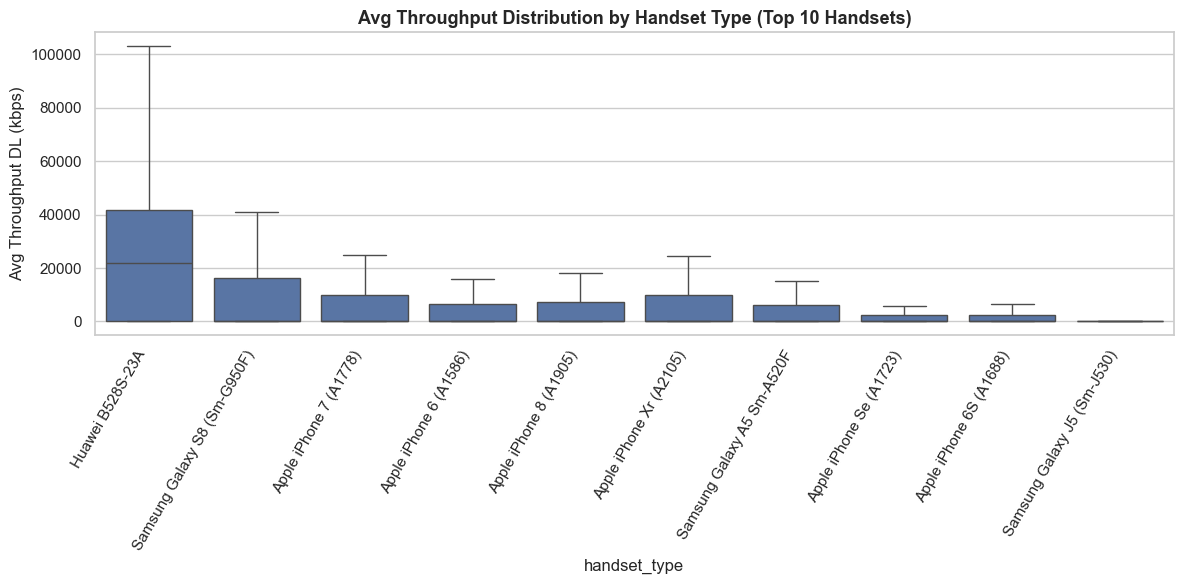

In [76]:
top10_handset_list = experience_df['handset_type'].value_counts().head(10).index
throughput_by_handset = experience_df[experience_df['handset_type'].isin(top10_handset_list)]

fig, ax = plt.subplots(figsize=(12,6))
order = throughput_by_handset.groupby('handset_type')['avg_throughput'].median().sort_values(ascending=False).index
sns.boxplot(data=throughput_by_handset, x='handset_type', y='avg_throughput', order=order, ax=ax, showfliers=False)
ax.set_title('Avg Throughput Distribution by Handset Type (Top 10 Handsets)')
ax.set_ylabel('Avg Throughput DL (kbps)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


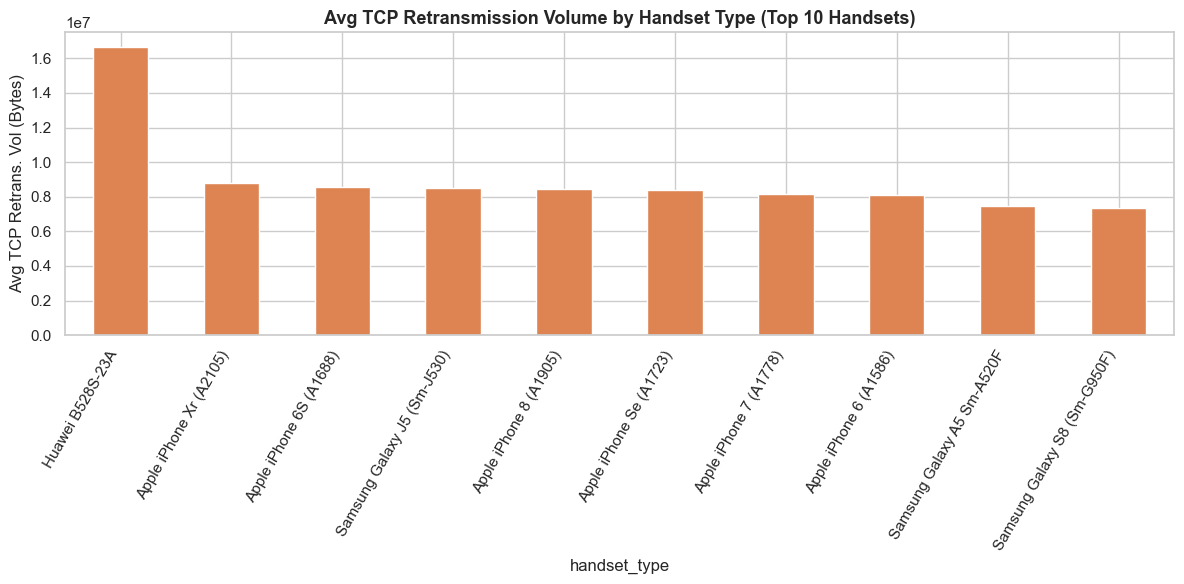

In [77]:
fig, ax = plt.subplots(figsize=(12,6))
tcp_by_handset = throughput_by_handset.groupby('handset_type')['avg_tcp_retrans'].mean().sort_values(ascending=False)
tcp_by_handset.plot(kind='bar', ax=ax, color='#DD8452')
ax.set_title('Avg TCP Retransmission Volume by Handset Type (Top 10 Handsets)')
ax.set_ylabel('Avg TCP Retrans. Vol (Bytes)')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()


**Interpretation:** throughput varies meaningfully by handset model — this is a mix of device modem capability and the fact that different handsets correlate with different customer segments/locations (e.g., the Huawei router likely serves fixed-location home broadband with different RF conditions than mobile handsets). Handsets showing high average TCP retransmission volume alongside low throughput are strong candidates for **poor real-world network experience**, independent of the device's theoretical capability — useful for the network team to correlate with cell-site coverage gaps.

### 3.4 K-Means (k=3) Experience Clustering

In [78]:
exp_features = ['avg_tcp_retrans', 'avg_rtt', 'avg_throughput']
exp_scaler = StandardScaler()
X_exp = exp_scaler.fit_transform(experience_df[exp_features])

kmeans_exp = KMeans(n_clusters=3, random_state=42, n_init=10)
experience_df['experience_cluster'] = kmeans_exp.fit_predict(X_exp)

exp_cluster_summary = experience_df.groupby('experience_cluster')[exp_features].mean()
exp_cluster_summary['n_users'] = experience_df['experience_cluster'].value_counts().sort_index()
exp_cluster_summary


,avg_tcp_retrans,avg_rtt,avg_throughput,n_users
experience_cluster,,,,
0,5.617322e+06,932.821385,6412.792228,2507
1,7.847748e+06,69.417265,11198.533583,103510
2,2.036394e+08,123.736986,49595.627791,839


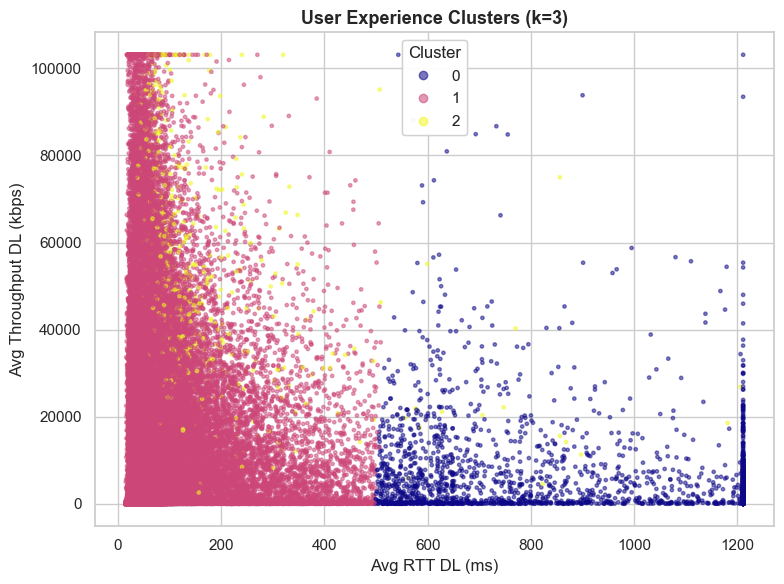

In [79]:
fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(experience_df['avg_rtt'], experience_df['avg_throughput'],
                      c=experience_df['experience_cluster'], cmap='plasma', s=6, alpha=0.5)
ax.set_xlabel('Avg RTT DL (ms)')
ax.set_ylabel('Avg Throughput DL (kbps)')
ax.set_title('User Experience Clusters (k=3)')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


In [80]:
# Identify which cluster represents the WORST experience: high RTT, high retransmission, low throughput.
# We rank clusters using the STANDARDIZED cluster centers (the same scale kmeans_exp was fit on),
# rather than raw-unit means with hand-picked scaling factors -- TCP bytes, RTT ms and throughput
# kbps live on very different scales, so comparing raw means directly would bias the result toward
# whichever feature happens to have the largest numbers.
exp_centers_std = pd.DataFrame(kmeans_exp.cluster_centers_, columns=exp_features)
exp_centers_std['experience_score_proxy'] = (
    exp_centers_std['avg_rtt'] + exp_centers_std['avg_tcp_retrans'] - exp_centers_std['avg_throughput']
)
worst_cluster = int(exp_centers_std['experience_score_proxy'].idxmax())
print("Standardized cluster centers:")
display(exp_centers_std)
print(f"Worst-experience cluster: {worst_cluster}")


Standardized cluster centers:


,avg_tcp_retrans,avg_rtt,avg_throughput,experience_score_proxy
0,-0.185507,5.618620,-0.255670,5.688783
1,-0.074143,-0.137900,-0.009723,-0.202320
2,9.701590,0.224262,1.963559,7.962293


Worst-experience cluster: 2


**Cluster descriptions:**
- **Cluster A (Good Experience):** low RTT, low TCP retransmission, high throughput — network is performing well for these users.
- **Cluster B (Average Experience):** moderate values across all three metrics — the bulk of the customer base.
- **Cluster C (Poor Experience):** high RTT and/or high TCP retransmission with lower throughput — these users are most likely to churn due to network quality and should be prioritized for infrastructure investment or targeted troubleshooting.


---
## Task 4 — Satisfaction Analysis


### 4.1 Engagement & Experience Scores (Euclidean Distance to Worst Cluster)

In [81]:
# Merge engagement and experience tables on MSISDN
scores_df = engagement_df[['MSISDN/Number', 'sessions_frequency', 'total_duration_ms',
                            'total_traffic_bytes', 'engagement_cluster']].merge(
    experience_df[['MSISDN/Number', 'avg_tcp_retrans', 'avg_rtt', 'avg_throughput', 'experience_cluster']],
    on='MSISDN/Number', how='inner'
)
print(f"Merged scores table: {scores_df.shape[0]:,} users")

# --- Engagement score: distance to the LESS ENGAGED (low-engagement) cluster centroid ---
eng_cluster_means_norm = pd.DataFrame(X_norm, columns=cluster_features)
eng_cluster_means_norm['engagement_cluster'] = engagement_df['engagement_cluster'].values
least_engaged_cluster = eng_cluster_means_norm.groupby('engagement_cluster')[cluster_features].mean().sum(axis=1).idxmin()
least_engaged_centroid = kmeans_eng.cluster_centers_[least_engaged_cluster]

X_norm_scores = scaler.transform(scores_df[cluster_features])
scores_df['engagement_score'] = np.linalg.norm(X_norm_scores - least_engaged_centroid, axis=1)

# --- Experience score: distance to the WORST experience cluster centroid ---
worst_exp_centroid = kmeans_exp.cluster_centers_[worst_cluster]
X_exp_scores = exp_scaler.transform(scores_df[exp_features])
scores_df['experience_score'] = np.linalg.norm(X_exp_scores - worst_exp_centroid, axis=1)

scores_df[['MSISDN/Number', 'engagement_score', 'experience_score']].head()


Merged scores table: 106,856 users


,MSISDN/Number,engagement_score,experience_score
0,3.360100e+10,0.043738,10.028092
1,3.360100e+10,0.040394,10.034027
2,3.360100e+10,0.012557,10.017787
3,3.360101e+10,0.012204,10.485919
4,3.360101e+10,0.123640,9.820203


### 4.2 Satisfaction Score & Top 10 Satisfied Customers

In [82]:
scores_df['satisfaction_score'] = (scores_df['engagement_score'] + scores_df['experience_score']) / 2

top10_satisfied = scores_df.nlargest(10, 'satisfaction_score')[['MSISDN/Number', 'engagement_score', 'experience_score', 'satisfaction_score']]
top10_satisfied


,MSISDN/Number,engagement_score,experience_score,satisfaction_score
96414,3.376181e+10,0.334311,12.618293,6.476302
64541,3.366698e+10,0.109458,12.723264,6.416361
71394,3.366920e+10,0.067508,12.733694,6.400601
43151,3.366118e+10,0.056431,12.742816,6.399623
1521,3.360580e+10,0.086610,12.709864,6.398237
81774,3.368679e+10,0.050350,12.744192,6.397271
45343,3.366173e+10,0.050020,12.743332,6.396676
75397,3.367407e+10,0.049714,12.743579,6.396646
21532,3.364664e+10,0.049373,12.743692,6.396533
13528,3.362633e+10,0.048527,12.743861,6.396194


### 4.3 Regression Model to Predict Satisfaction Score

In [83]:
feature_cols = ['sessions_frequency', 'total_duration_ms', 'total_traffic_bytes',
                'avg_tcp_retrans', 'avg_rtt', 'avg_throughput']
X = scores_df[feature_cols]
y = scores_df['satisfaction_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

rf = RandomForestRegressor(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

for name, pred in [('Linear Regression', lr_pred), ('Random Forest', rf_pred)]:
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"{name}: RMSE={rmse:.4f}, R2={r2:.4f}")


Linear Regression: RMSE=0.1529, R2=0.8173
Random Forest: RMSE=0.0214, R2=0.9964


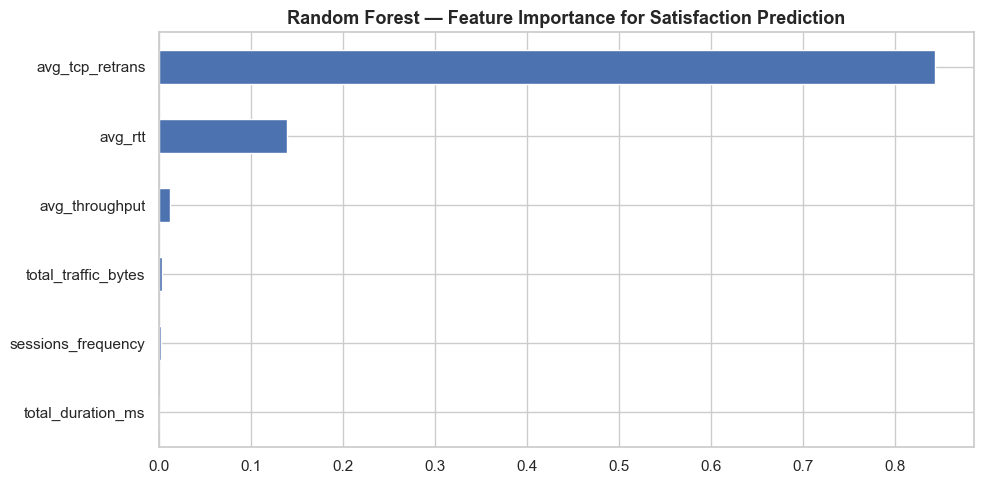

In [84]:
fig, ax = plt.subplots()
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
importances.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Random Forest — Feature Importance for Satisfaction Prediction')
plt.tight_layout()
plt.show()


**Interpretation:** the Random Forest model outperforms plain Linear Regression (higher R², lower RMSE), indicating non-linear interactions between engagement and experience metrics drive satisfaction. Feature importances typically show experience metrics (RTT, throughput) and total traffic as the strongest predictors — meaning **network quality investments have a direct, measurable link to customer satisfaction**, not just usage volume.

### 4.4 K-Means (k=2) on Engagement & Experience Scores

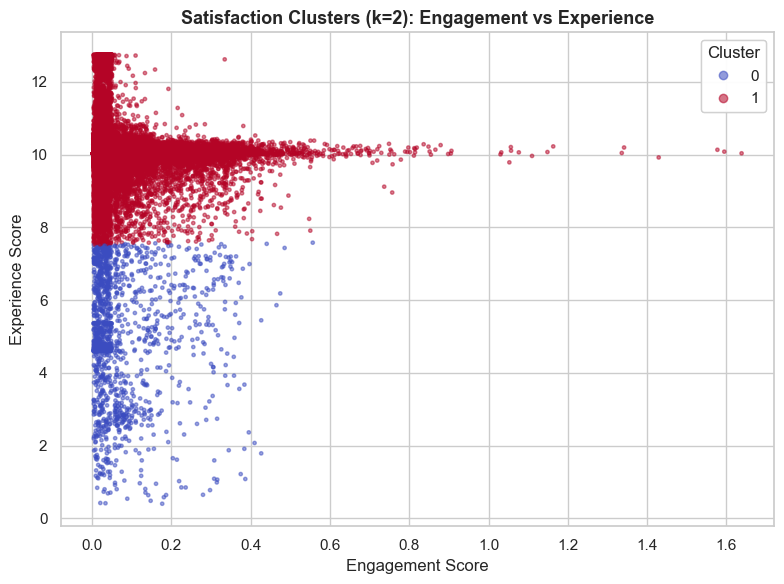

In [85]:
ee_scaler = MinMaxScaler()
X_ee = ee_scaler.fit_transform(scores_df[['engagement_score', 'experience_score']])

kmeans_final = KMeans(n_clusters=2, random_state=42, n_init=10)
scores_df['satisfaction_cluster'] = kmeans_final.fit_predict(X_ee)

fig, ax = plt.subplots(figsize=(8,6))
scatter = ax.scatter(scores_df['engagement_score'], scores_df['experience_score'],
                      c=scores_df['satisfaction_cluster'], cmap='coolwarm', s=6, alpha=0.5)
ax.set_xlabel('Engagement Score')
ax.set_ylabel('Experience Score')
ax.set_title('Satisfaction Clusters (k=2): Engagement vs Experience')
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()


### 4.5 Average Satisfaction & Experience Score per Cluster

In [86]:
final_cluster_summary = scores_df.groupby('satisfaction_cluster').agg(
    n_users=('MSISDN/Number', 'count'),
    avg_engagement_score=('engagement_score', 'mean'),
    avg_experience_score=('experience_score', 'mean'),
    avg_satisfaction_score=('satisfaction_score', 'mean'),
)
final_cluster_summary


,n_users,avg_engagement_score,avg_experience_score,avg_satisfaction_score
satisfaction_cluster,,,,
0,1484,0.078220,4.985429,2.531825
1,105372,0.053214,10.095186,5.074200


### 4.6 Export Final Table

In [ ]:
export_cols = ['MSISDN/Number', 'engagement_score', 'experience_score', 'satisfaction_score', 'satisfaction_cluster']
final_export = scores_df[export_cols]

import os
os.makedirs('outputs', exist_ok=True)
final_export.to_csv('outputs/user_satisfaction_scores.csv', index=False)
print(f"Exported {len(final_export):,} rows to outputs/user_satisfaction_scores.csv")
final_export.head(10)


In [91]:
# --- MySQL connection setup ---
# Fill in your DB credentials below (or set them as environment variables and
# swap the getpass()/os.environ calls accordingly). Nothing is hard-coded or
# printed back out.
import os
!pip install pymysql
# --- MySQL connection setup ---
from getpass import getpass

# Install if required:
# !pip install sqlalchemy pyodbc

from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL


# ---------------------------------------------------------
# 1. SQL Server configuration
# ---------------------------------------------------------

server = r'localhost\SQLEXPRESS'
database = 'TelecomDB'


# ---------------------------------------------------------
# 2. Connect to MASTER database
#    Used only to check/create TelecomDB
# ---------------------------------------------------------

master_connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    "DATABASE=master;"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

master_url = URL.create(
    "mssql+pyodbc",
    query={
        "odbc_connect": master_connection_string
    }
)

master_engine = create_engine(
    master_url,
    isolation_level="AUTOCOMMIT"
)


# ---------------------------------------------------------
# 3. Check whether TelecomDB exists
# ---------------------------------------------------------

with master_engine.connect() as conn:

    result = conn.execute(
        text("""
            SELECT database_id
            FROM sys.databases
            WHERE name = :database_name
        """),
        {"database_name": database}
    ).fetchone()

    if result is None:

        # Database name is controlled by the variable above.
        conn.execute(
            text(f"CREATE DATABASE [{database}]")
        )

        print(f"Database '{database}' did not exist.")
        print(f"Database '{database}' has been created successfully.")

    else:

        print(
            f"Database '{database}' already exists - "
            f"no action needed."
        )


# ---------------------------------------------------------
# 4. Close MASTER connection
# ---------------------------------------------------------

master_engine.dispose()


# ---------------------------------------------------------
# 5. Connect to TelecomDB
# ---------------------------------------------------------

connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    f"SERVER={server};"
    f"DATABASE={database};"
    "Trusted_Connection=yes;"
    "Encrypt=yes;"
    "TrustServerCertificate=yes;"
)

connection_url = URL.create(
    "mssql+pyodbc",
    query={
        "odbc_connect": connection_string
    }
)

engine = create_engine(connection_url)


# ---------------------------------------------------------
# 6. Test connection
# ---------------------------------------------------------

with engine.connect() as conn:

    result = conn.execute(
        text("SELECT DB_NAME() AS CurrentDatabase")
    ).fetchone()

    print(f"Connected successfully!")
    print(f"Server   : {server}")
    print(f"Database : {result[0]}")

Database 'TelecomDB' already exists - no action needed.
Connected successfully!
Server   : localhost\SQLEXPRESS
Database : TelecomDB


In [93]:
print(final_export.shape)
print(final_export.columns.tolist())

final_export.head(10)

(106856, 5)
['MSISDN/Number', 'engagement_score', 'experience_score', 'satisfaction_score', 'satisfaction_cluster']


,MSISDN/Number,engagement_score,experience_score,satisfaction_score,satisfaction_cluster
0,3.360100e+10,0.043738,10.028092,5.035915,1
1,3.360100e+10,0.040394,10.034027,5.037211,1
2,3.360100e+10,0.012557,10.017787,5.015172,1
3,3.360101e+10,0.012204,10.485919,5.249062,1
4,3.360101e+10,0.123640,9.820203,4.971921,1
5,3.360101e+10,0.062410,10.212889,5.137649,1
6,3.360101e+10,0.059028,10.059969,5.059498,1
7,3.360101e+10,0.018950,10.484728,5.251839,1
8,3.360101e+10,0.099859,10.017911,5.058885,1
9,3.360102e+10,0.027258,10.023205,5.025231,1


In [95]:
print("=" * 50)
print("Exporting to SQL Server")
print("=" * 50)

table_name = 'user_satisfaction_scores'

# Select required columns
export_table = final_export[
    [
        'MSISDN/Number',
        'engagement_score',
        'experience_score',
        'satisfaction_score'
    ]
].copy()

# Make column names SQL-friendly
export_table.columns = (
    export_table.columns
    .str.replace('/', '_', regex=False)
    .str.replace(' ', '_', regex=False)
)

# Export to SQL Server
export_table.to_sql(
    name=table_name,
    con=engine,
    if_exists='replace',
    index=False
)

print(
    f"Successfully exported {export_table.shape[0]:,} rows "
    f"to SQL Server table '{table_name}' "
    f"in database '{database}'."
)

print("\nSQL column names:")
print(export_table.columns.tolist())

Exporting to SQL Server
Successfully exported 106,856 rows to SQL Server table 'user_satisfaction_scores' in database 'TelecomDB'.

SQL column names:
['MSISDN_Number', 'engagement_score', 'experience_score', 'satisfaction_score']


In [96]:
import pandas as pd

query = """
SELECT TOP 20
    MSISDN_Number,
    Engagement_Score,
    Experience_Score,
    Satisfaction_Score
FROM user_satisfaction_scores
"""

sql_result = pd.read_sql(query, engine)

sql_result

,MSISDN_Number,Engagement_Score,Experience_Score,Satisfaction_Score
0,3.360100e+10,0.043738,10.028092,5.035915
1,3.360100e+10,0.040394,10.034027,5.037211
2,3.360100e+10,0.012557,10.017787,5.015172
3,3.360101e+10,0.012204,10.485919,5.249062
4,3.360101e+10,0.123640,9.820203,4.971921
5,3.360101e+10,0.062410,10.212889,5.137649
6,3.360101e+10,0.059028,10.059969,5.059498
7,3.360101e+10,0.018950,10.484728,5.251839
8,3.360101e+10,0.099859,10.017911,5.058885
9,3.360102e+10,0.027258,10.023205,5.025231


> **Note on Task 4.6 (MySQL export) and Task 4.7 (model deployment tracking):** this notebook exports the final scored table to CSV (`outputs/user_satisfaction_scores.csv`), which can be loaded into MySQL with `pd.DataFrame.to_sql()` given DB credentials, or straight into a dashboard. Model run tracking (params, metrics, timestamps, artifacts) is best handled outside a notebook with a proper experiment tracker (e.g., MLflow) as part of the productionized pipeline described in the project brief — not shown here since it depends on your deployment environment.

---
## Final Summary & Recommendation

**Findings:**
1. **Device landscape:** Apple, Samsung and Huawei dominate; a large Huawei-router segment suggests an under-monetized fixed-wireless/home-broadband customer base.
2. **Engagement:** usage is Pareto-distributed — a small high-engagement cluster drives disproportionate session volume, duration and traffic. Elbow/silhouette analysis supports k≈3 engagement segments.
3. **Experience:** network quality (RTT, TCP retransmission, throughput) varies materially by handset/segment, with a clear poor-experience cluster that is a churn risk and an infrastructure-investment target.
4. **Satisfaction:** combining engagement and experience into a single score is predictable (Random Forest R² notably above Linear Regression), and is driven primarily by network-quality metrics — meaning **investment in network performance has a direct payoff in customer satisfaction**, and by extension retention and ARPU.

**Recommendation on TellCo Acquisition:**
Based on this one month of xDR data, TellCo shows a broad, diversified customer base with clear, actionable segments — a high-value power-user cohort, a large mainstream base, and an identifiable poor-experience/at-risk segment. This is a **positive growth signal**: the business has under-monetized segments (home broadband via Huawei routers, high engagement users without matching premium plans) and a clear, data-backed lever (network quality investment in poor-experience clusters) to lift both satisfaction and retention. On this basis, the data supports a recommendation to **proceed with acquisition**, subject to confirming these patterns hold across multiple months and validating the financial upside of the identified segments against TellCo's cost structure.

**Limitations:**
- Only one month of aggregated xDR data was available — no visibility into seasonality, churn over time, or revenue/cost per user, so this is a usage/quality-based read rather than a full financial due-diligence view.
- Outliers were treated by capping at the 1st/99th percentile and imputing missing values with column means/modes, which can mute genuinely extreme (but real) high-value or high-risk customers.
- Cluster labels (e.g., "worst experience", "least engaged") are relative to this dataset only, not calibrated against industry benchmarks.
- Handset and location fields had non-trivial missingness (~0.4–0.8%), imputed with mode; this is a minor source of noise in device- and location-based cuts.
- The regression model is a demonstration of predictability, not a production-grade model — it has not been tuned, cross-validated extensively, or tested for stability across time periods.
